
# **Bank Marketing Campaign Prediction**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# SPRINT 1 : DATA UNDERSTADING & PREPROCESSING

### Problem Statement
The main objective of this project is to predict whether a customer will subscribe to a bank term deposit based on their demographic and campaign-related information.

This helps banks identify potential customers and improve marketing efficiency.
Banks spend a lot of money on marketing campaigns.

However, not every customer subscribes to a term deposit after being contacted.

So, it becomes difficult for banks to identify interested customers.

To solve this problem, I developed a machine learning model that predicts whether a customer will subscribe to a term deposit or not.

The target variable in the dataset is "y", where:


*   Yes = Customer subscribes
*   No = Customer does not subscribe


## Step 1 : Data collection & loading

In [ ]:
#Import Libraries
import numpy as np       # NumPy → Numerical operations and arrays
import pandas as pd       # Pandas → Data manipulation and analysis
import matplotlib.pyplot as plt     # Matplotlib → Data visualization and plotting
import seaborn as sns              # Seaborn → Advanced statistical visualizations

In [ ]:
# IMPORT LIBRARIES
import zipfile

# ZIP FILE PATH
zip_path = "/content/Banking_Customer_Account-20260519T064724Z-3-001 - Copy.zip"

# EXTRACT ZIP FILE
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/data')

df = pd.read_csv('/content/data/Banking_Customer_Account/train.csv',sep=';')
print(df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [ ]:
df.info() #The dataset contains customer information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
# validate
df.shape
# Returns the number of rows and columns present in the dataset.

(45211, 17)

In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

# Step 2 : Initial  Data Inspection

### Perform:

In [ ]:
df.head()   # Displays the first 5 rows of the dataset.

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
df.tail()     # Displays the last 5 rows of the dataset.

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [ ]:
df.describe() #Gives statistical summary for numerical columns.

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### Check:

In [ ]:
df.dtypes
# Displays the data type of each column in the dataset.

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [ ]:
df.isnull().sum()
# Returns the total number of missing (null) values in each column of the dataset.

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
df.duplicated() #Returns True for duplicate rows.

,0
0,False
1,False
2,False
3,False
4,False
...,...
45206,False
45207,False
45208,False
45209,False


In [ ]:
for col in df.columns:
    print(col, df[col].nunique())

age 77
job 12
marital 3
education 4
default 2
balance 7168
housing 2
loan 2
contact 3
day 31
month 12
duration 1573
campaign 48
pdays 559
previous 41
poutcome 4
y 2




*  for → Loop through columns.

*  df.columns → List of column names.

*  print() → Displays output.
*  df[col] → Select specific column.


*  .nunique() → Counts unique values.





In [ ]:
df.dtypes  #Used before preprocessing.

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


# Step 3 : Data Cleaning

In [ ]:
df.drop_duplicates(inplace=True)



* .drop_duplicates() → Removes duplicate records  
*   inplace=True → Changes original DataFrame directly.



In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')




*   .str.strip() → Removes extra spaces.

*  .str.lower() → Converts names to lowercase.
*  .str.replace(" ", "_") → Replaces spaces with underscore.



# Step 4 : Exploratory Data Analysis

In [ ]:
X = df.drop('y',axis=1)
y = df['y']



*  X → Independent variables (features).

*   y → Target/output column.
* .drop('y', axis=1) → Removes target column from features.


*  axis=1 → Refers to columns.



### Univariate Analysis

Univariate Analysis
* Histograms were used to study feature distributions.

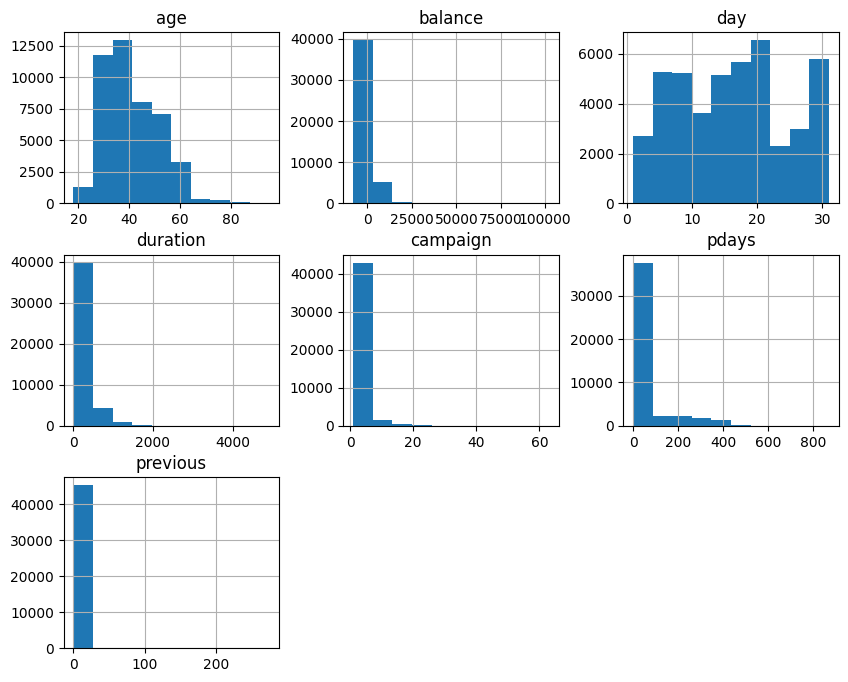

In [ ]:
df.hist(figsize=(10,8))
plt.show()



*   .hist() → Creates histogram for numerical columns.

*  figsize=(10,8) → Graph size.
* plt.show() → Displays graph.
* Purpose:

*  Understand data distribution.



In [ ]:
num_cols = X.select_dtypes(include=['int','float']).columns
cat_cols = X.select_dtypes(include='object').columns



*  .select_dtypes() → Select columns based on datatype.

*  include=['int','float'] → Numerical columns.
*  include='object' → Categorical columns.


*  .columns → Returns column names.



In [ ]:
X[num_cols].skew()

,0
age,0.684818
balance,8.360308
day,0.093079
duration,3.144318
campaign,4.898650
pdays,2.615715
previous,41.846454




*  .skew() → Measures asymmetry of distribution.




### Bivariate


Bivariate Analysis
* Count plots were used to analyze the relationship between customer jobs and subscription status.

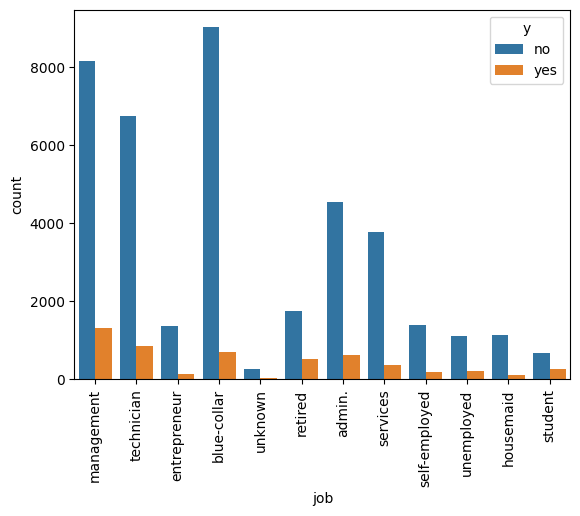

In [ ]:
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=90)
plt.show()



*  sns.countplot() → Shows frequency count.

*  x='job' → Job categories on X-axis.
*   hue='y' → Split bars based on target variable.


*   rotation=90 → Rotates labels.



Correlation Analysis

* Heatmaps were used to identify relationships among numerical features.

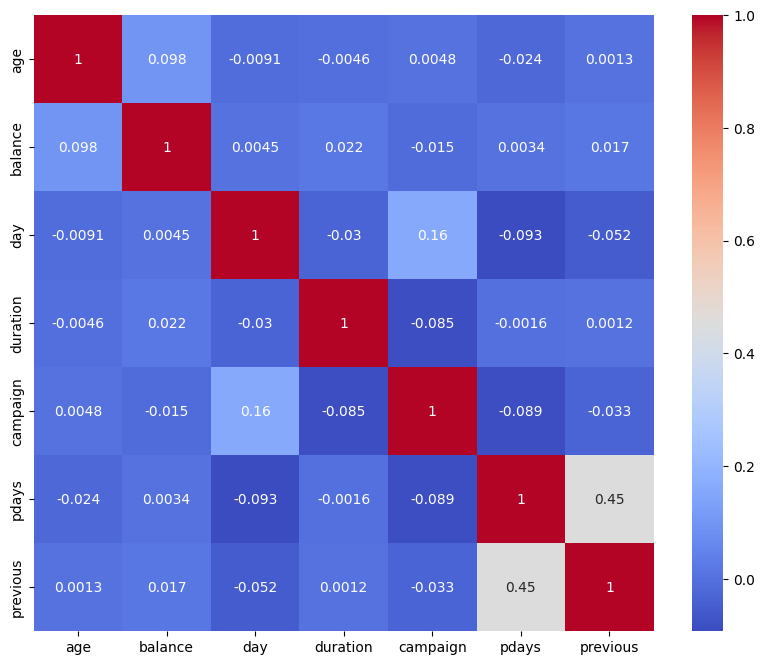

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()



*   .corr() → Computes correlation between numerical columns.

*  numeric_only=True → Uses only numeric columns.

*   plt.figure() → Creates plotting area.
*   sns.heatmap() → Displays correlation matrix visually.


* annot=True → Shows correlation values.


*  cmap='coolwarm' → Color style.


### Multi Variate

Multivariate Analysis
* Pair plots were generated to observe interactions among multiple variables.

* EDA helped identify patterns and trends in customer behavior.

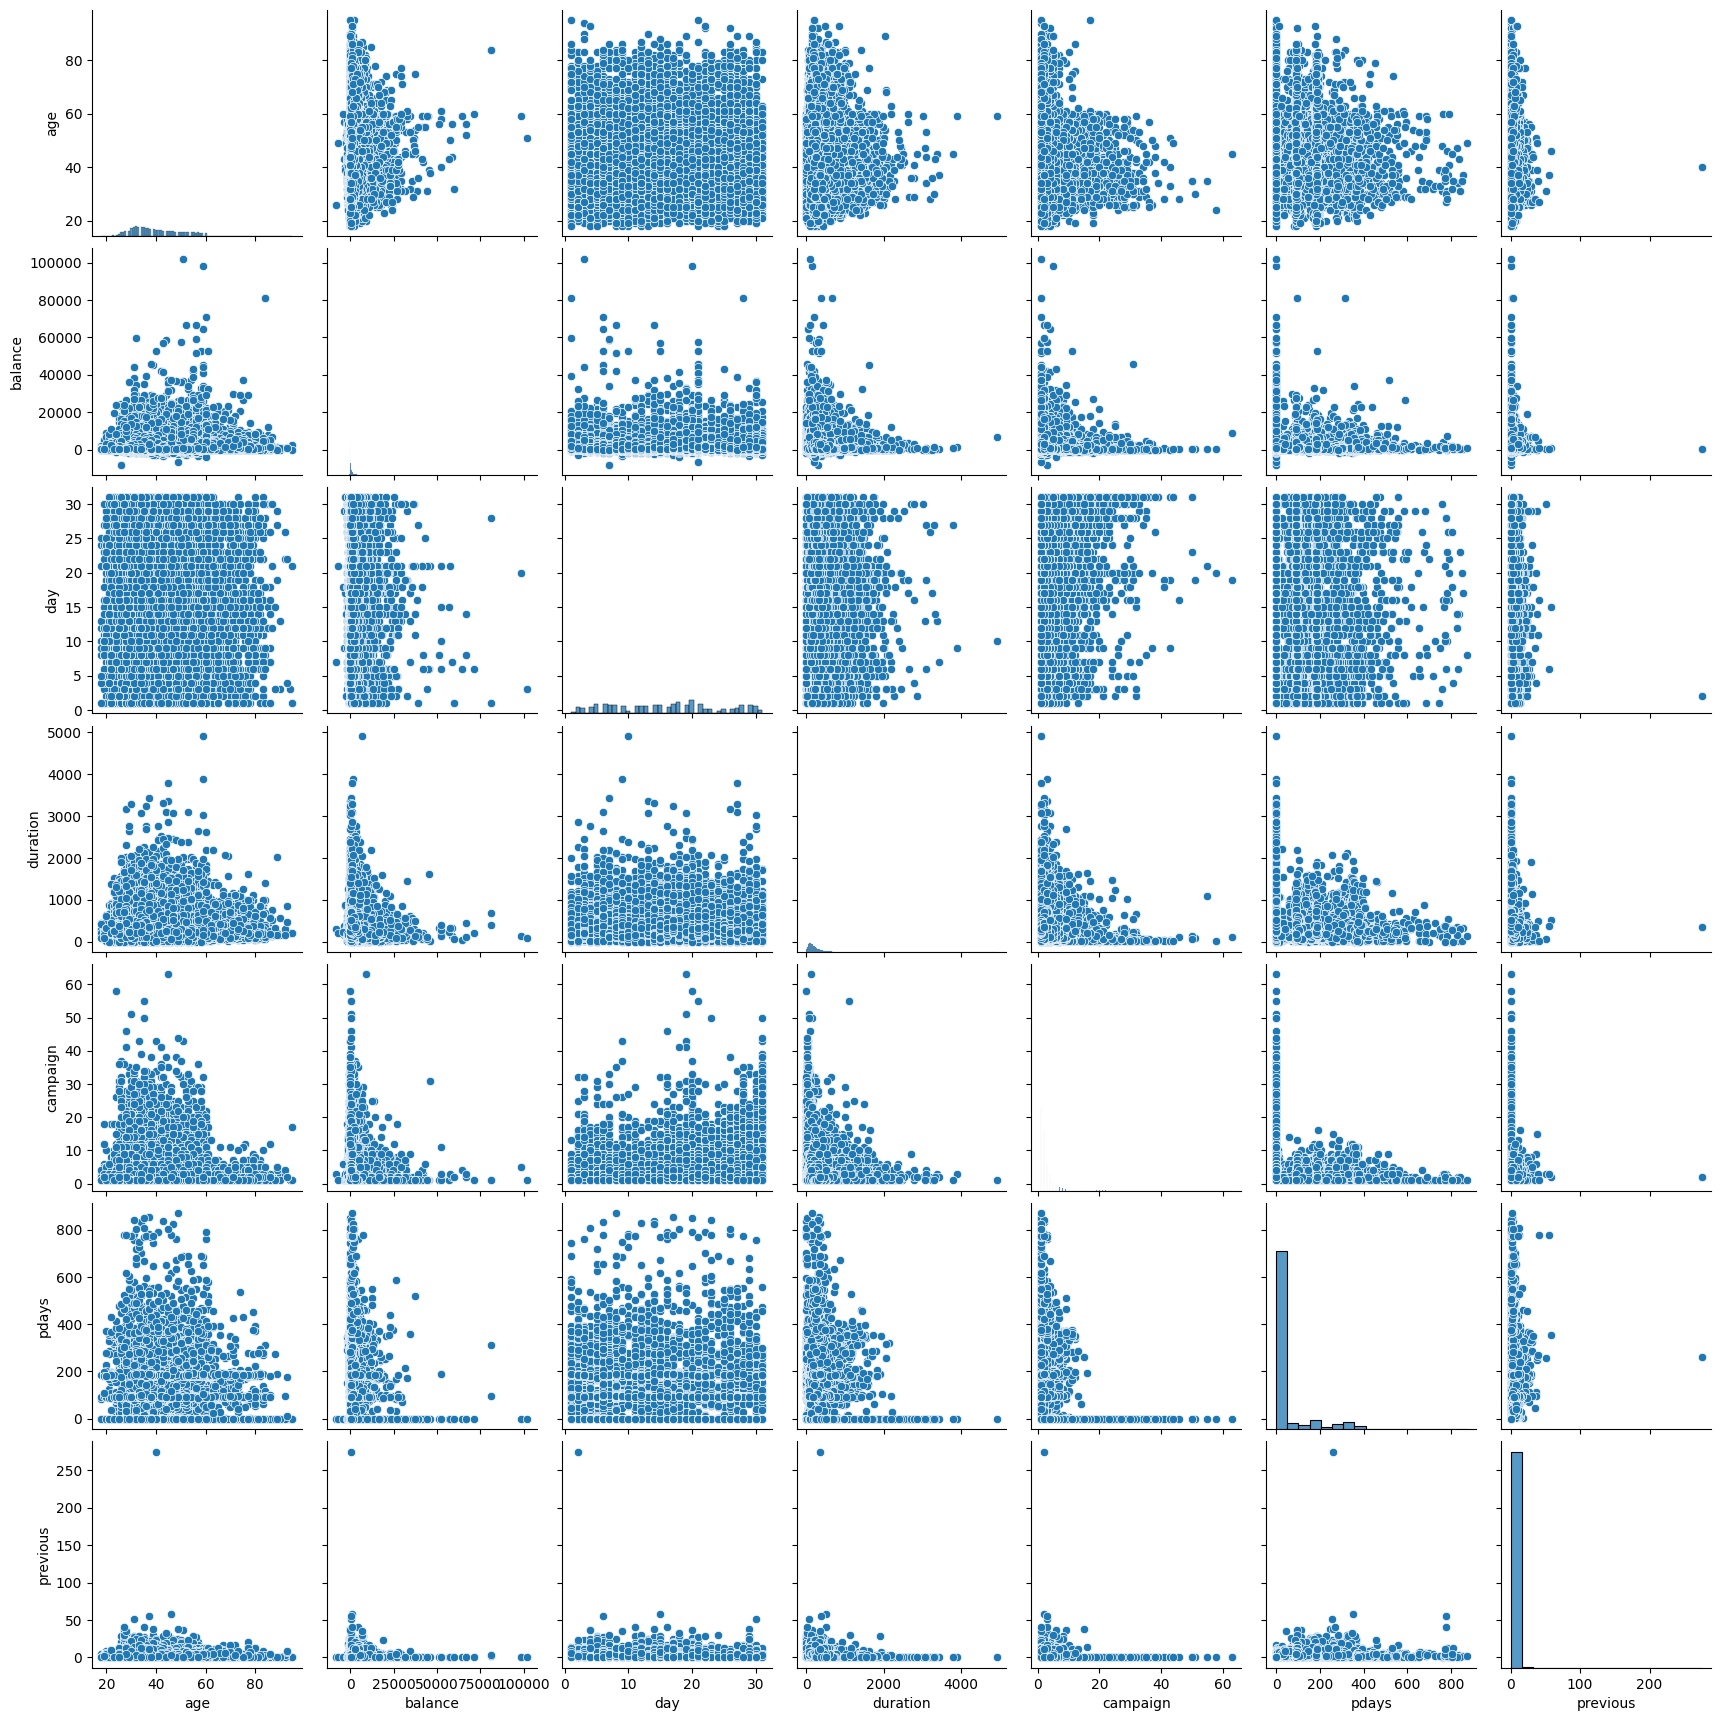

In [ ]:
sns.pairplot(df)
plt.show()



*   pairplot() → Shows pairwise relationships.

*  Includes:
* Scatter plots


*  Histograms



# Step 5: Outlier Detection & Treatment

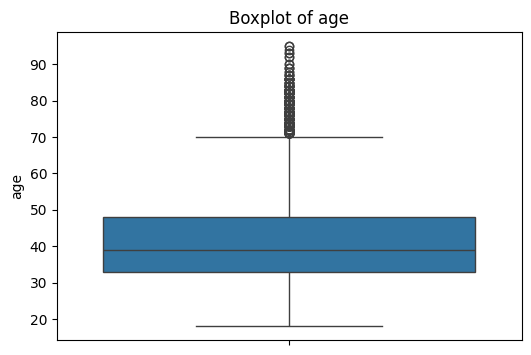

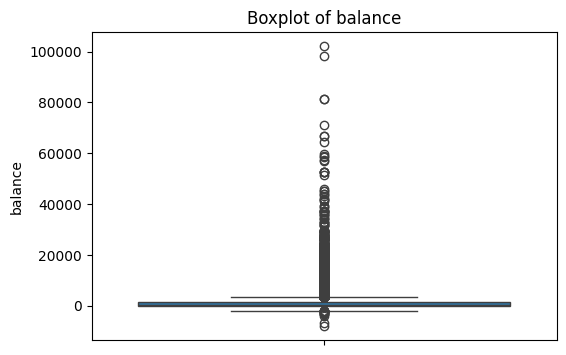

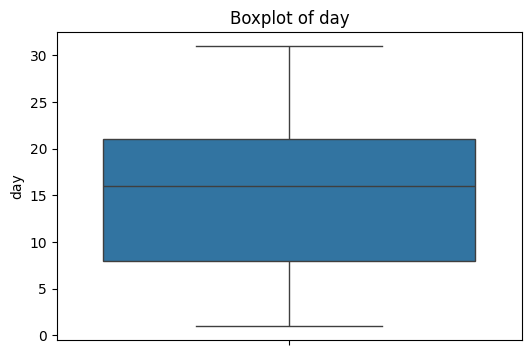

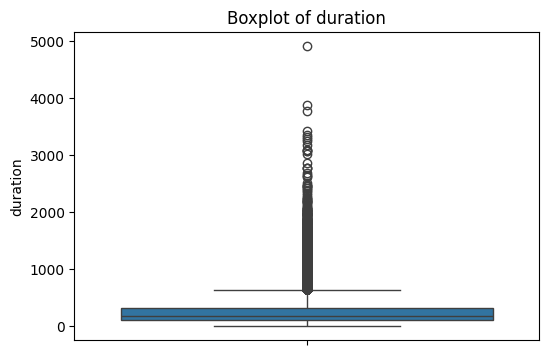

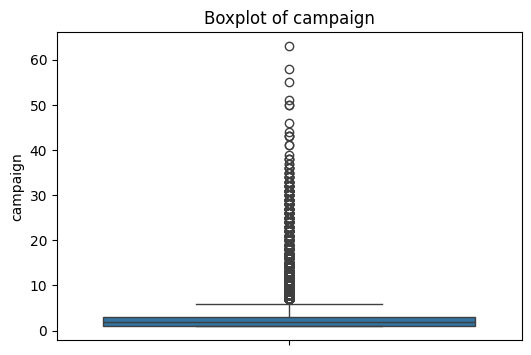

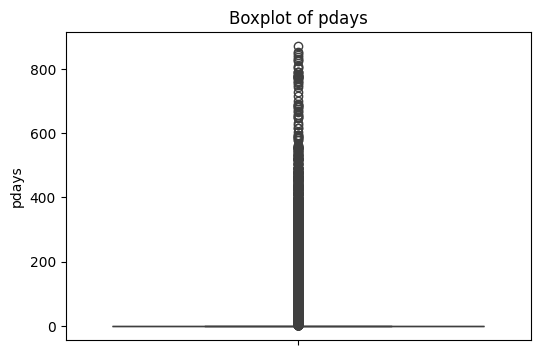

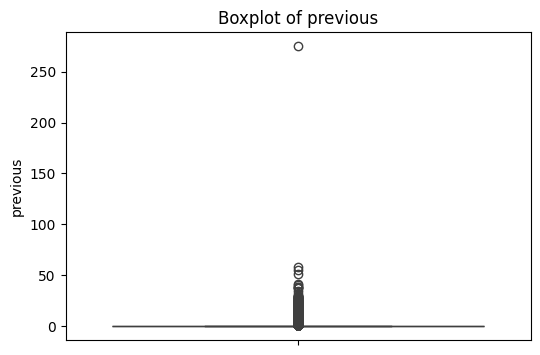

In [ ]:
# Boxplots
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(X[col])
    plt.title(f'Boxplot of {col}')
    plt.show()





*   for col in num_cols → Loop through numerical columns.

*   sns.boxplot() → Detects outliers.

* plt.title() → Adds graph title.








Outliers can negatively affect model performance.

To handle outliers:

* Boxplots were used to detect extreme values.
* IQR (Interquartile Range) method was applied.
* Values beyond upper and lower limits were capped.
This reduced data skewness and improved model reliability.

# Step 6: Feature Encoding

In [ ]:
# IQR Method
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Capping outliers
    df[col] = np.where(df[col] > upper, upper, df[col])
    df[col] = np.where(df[col] < lower, lower, df[col])



*   Explanation
Q1 → 25th percentile.
Q3 → 75th percentile.
IQR → Interquartile Range.



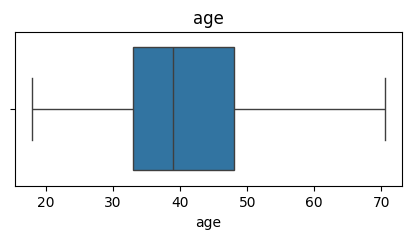

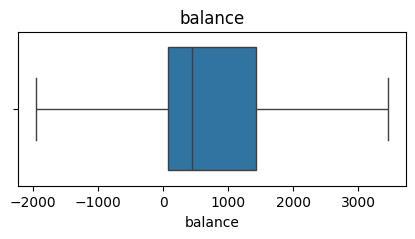

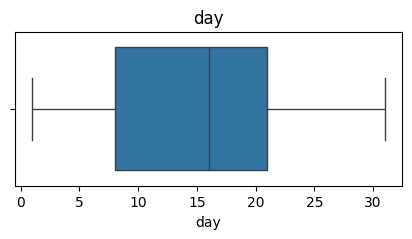

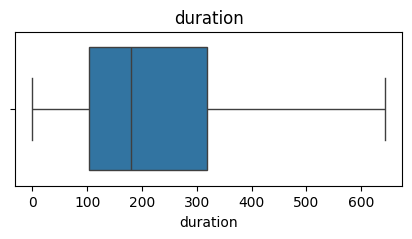

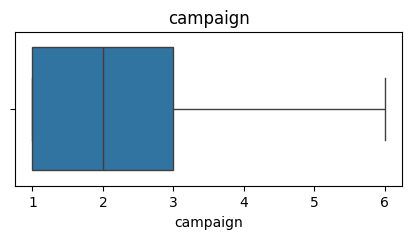

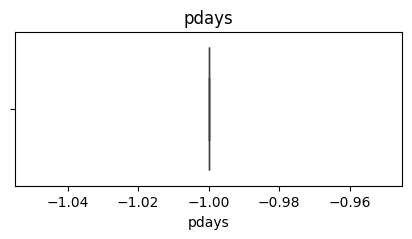

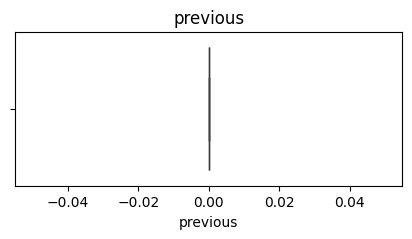

In [ ]:
# Boxplots
for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Used to verify whether outliers are reduced.

# Step 7: Feature Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)



*   train_test_split → Splits data into train and test.
*   ColumnTransformer → Applies transformations to selected columns.

*   StandardScaler → Scales numerical data.
*  OneHotEncoder → Converts categorical data into numerical format.





# Step 8: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print( X_train.shape)
print( X_test.shape)
print( y_train.shape)
print( y_test.shape)

(36168, 16)
(9043, 16)
(36168,)
(9043,)




*   train_test_split() → Splits dataset.
*   test_size=0.2 → 20% testing data.


*  random_state=42 → Ensures reproducible results.





In [ ]:
pd.DataFrame(X_train_transformed, columns=preprocessor.get_feature_names_out())

,num__age,num__balance,num__day,num__duration,num__campaign,num__pdays,num__previous,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,...,cat__month_jun,cat__month_mar,cat__month_may,cat__month_nov,cat__month_oct,cat__month_sep,cat__poutcome_failure,cat__poutcome_other,cat__poutcome_success,cat__poutcome_unknown
0,0.006515,-0.169381,-0.098218,-0.719756,-0.565886,-0.411364,-0.244772,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.759937,0.017848,1.703422,0.047138,-0.245389,-0.411364,-0.244772,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.100693,0.820681,1.823532,-0.493970,0.395606,-0.411364,-0.244772,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.370196,-0.489588,-0.578656,0.459781,2.639088,-0.411364,-0.244772,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.419181,0.706889,-0.098218,0.027674,-0.245389,-0.411364,-0.244772,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36163,0.289048,-0.099915,0.262110,7.147714,-0.565886,-0.411364,-0.244772,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
36164,-1.688684,-0.282181,-0.938984,-0.182541,-0.565886,0.517649,0.177056,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
36165,-0.652729,-0.014570,-0.098218,-0.069648,-0.565886,-0.411364,-0.244772,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
36166,-0.746907,-0.395643,-1.059093,-0.567934,-0.565886,-0.411364,-0.244772,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0





*   pd.DataFrame() → Converts transformed array into DataFrame.
*   X_train_transformed → Processed training data.

*   get_feature_names_out() → Retrieves transformed column names.








# SPRINT 2: MODEL BUILDING & EVALUATION

# Step 1: Baseline Model

In [3]:
# I trained and compared five machine learning algorithms:

# Logistic Regression
# Decision Tree
# Random Forest
# Support Vector Machine (SVM)
# Naive Bayes

# Each model was trained using the same preprocessed dataset.

# Their performance was evaluated using different evaluation metrics.

In [ ]:
from sklearn.linear_model import LogisticRegression
# Baseline Model
lr = LogisticRegression()

# Train
lr.fit(X_train_transformed, y_train)

# Prediction
y_pred_lr = lr.predict(X_test_transformed)

In [ ]:
print(y_pred_lr)

['no' 'no' 'no' ... 'no' 'no' 'no']


# Step 2: Train Multiple Models

## 1. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train_transformed, y_train)

y_pred_lr = lr.predict(X_test_transformed)

## 2. Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train_transformed, y_train)

y_pred_dt = dt.predict(X_test_transformed)

## 3. Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train_transformed, y_train)

y_pred_rf = rf.predict(X_test_transformed)

## 4. Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train_transformed, y_train)

y_pred_svm = svm.predict(X_test_transformed)

## 5. Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train_transformed, y_train)

y_pred_nb = nb.predict(X_test_transformed)

#Step 3: Model Evaluation

The following metrics were used:

* Accuracy

Measures overall correctness.

* Precision

Measures how many predicted positives are actually positive.

* Recall

Measures how many actual positives are identified correctly.

* F1 Score

Provides a balance between Precision and Recall.

* Confusion Matrix

Shows:

True Positives
True Negatives
False Positives
False Negatives

These metrics help compare model performance effectively.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def evaluate_model(y_test, y_pred):

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# Step 4: Overfitting & Underfitting Check

In [ ]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm,
    "Naive Bayes": nb
}

for name, model in models.items():

    # Training Prediction
    train_pred = model.predict(X_train_transformed)

    # Testing Prediction
    test_pred = model.predict(X_test_transformed)

    # Accuracy Scores
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print("\n", "="*50)
    print(name)
    print("="*50)

    print("Training Accuracy :", train_acc)
    print("Testing Accuracy  :", test_acc)

    # Overfitting Check
    if train_acc - test_acc > 0.10:
        print("Status : Overfitting")

    elif train_acc < 0.70 and test_acc < 0.70:
        print("Status : Underfitting")

    else:
        print("Status : Good Fit")


Logistic Regression
Training Accuracy : 0.90278699402787
Testing Accuracy  : 0.8987061815769103
Status : Good Fit

Decision Tree
Training Accuracy : 1.0
Testing Accuracy  : 0.8759261307088355
Status : Overfitting

Random Forest
Training Accuracy : 1.0
Testing Accuracy  : 0.9045670684507354
Status : Good Fit

SVM
Training Accuracy : 0.914980092899801
Testing Accuracy  : 0.9026871613402632
Status : Good Fit

Naive Bayes
Training Accuracy : 0.8525215660252157
Testing Accuracy  : 0.8458476169412805
Status : Good Fit


In [ ]:
import pandas as pd

results = pd.DataFrame({

    "Model": models.keys(),

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_nb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr, pos_label='yes'),
        precision_score(y_test, y_pred_dt, pos_label='yes'),
        precision_score(y_test, y_pred_rf, pos_label='yes'),
        precision_score(y_test, y_pred_svm, pos_label='yes'),
        precision_score(y_test, y_pred_nb, pos_label='yes')
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr, pos_label='yes'),
        recall_score(y_test, y_pred_dt, pos_label='yes'),
        recall_score(y_test, y_pred_rf, pos_label='yes'),
        recall_score(y_test, y_pred_svm, pos_label='yes'),
        recall_score(y_test, y_pred_nb, pos_label='yes')
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr, pos_label='yes'),
        f1_score(y_test, y_pred_dt, pos_label='yes'),
        f1_score(y_test, y_pred_rf, pos_label='yes'),
        f1_score(y_test, y_pred_svm, pos_label='yes'),
        f1_score(y_test, y_pred_nb, pos_label='yes')
    ],

    "Confusion Matrix": [
        confusion_matrix(y_test, y_pred_lr),
        confusion_matrix(y_test, y_pred_dt),
        confusion_matrix(y_test, y_pred_rf),
        confusion_matrix(y_test, y_pred_svm),
        confusion_matrix(y_test, y_pred_nb)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score  \
0  Logistic Regression  0.898706   0.653240  0.341888  0.448857   
1        Decision Tree  0.875926   0.485998  0.493126  0.489536   
2        Random Forest  0.904567   0.665217  0.420715  0.515441   
3                  SVM  0.902687   0.686067  0.356554  0.469240   
4          Naive Bayes  0.845848   0.393684  0.514207  0.445946   

            Confusion Matrix  
0  [[7754, 198], [718, 373]]  
1  [[7383, 569], [553, 538]]  
2  [[7721, 231], [632, 459]]  
3  [[7774, 178], [702, 389]]  
4  [[7088, 864], [530, 561]]  


#Step 5: Model Comparison Table

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score

# Assuming 'models' dictionary and X_train_transformed, X_test_transformed, y_train, y_test are available from previous cells.

data = {
    'Model': [],
    'Metric Score (Test Accuracy)': [],
    'Metric Score (Train Accuracy)': [],
    'Overfitting?': [],
    'Remarks': []
}

for name, model in models.items():
    train_score = model.score(X_train_transformed, y_train)
    test_score = model.score(X_test_transformed, y_test)

    overfitting_status = 'No'
    if train_score - test_score > 0.10:
        overfitting_status = 'Yes'
    elif train_score < 0.70 and test_score < 0.70:
        overfitting_status = 'Underfitting'
    else:
        overfitting_status = 'Good Fit'

    data['Model'].append(name)
    data['Metric Score (Test Accuracy)'].append(test_score)
    data['Metric Score (Train Accuracy)'].append(train_score)
    data['Overfitting?'].append(overfitting_status)

    remark = "Evaluated model"
    if name == "Logistic Regression":
        remark = "Baseline model"
    elif name == "Decision Tree":
        remark = "Prone to overfitting, high variance"
    elif name == "Random Forest":
        remark = "Good accuracy and stability, ensemble method"
    elif name == "SVM":
        remark = "Effective in high-dimensional spaces"
    elif name == "Naive Bayes":
        remark = "Simple and fast, good for classification"

    data['Remarks'].append(remark)

comparison = pd.DataFrame(data)
comparison

,Model,Metric Score (Test Accuracy),Metric Score (Train Accuracy),Overfitting?,Remarks
0,Logistic Regression,0.898706,0.902787,Good Fit,Baseline model
1,Decision Tree,0.875926,1.000000,Yes,"Prone to overfitting, high variance"
2,Random Forest,0.904567,1.000000,Good Fit,"Good accuracy and stability, ensemble method"
3,SVM,0.902687,0.914980,Good Fit,Effective in high-dimensional spaces
4,Naive Bayes,0.845848,0.852522,Good Fit,"Simple and fast, good for classification"


After evaluating all models:

* Logistic Regression provided a strong baseline.
* Decision Tree showed signs of overfitting.
* Random Forest provided stable performance.
* SVM performed well in high-dimensional data.
* Naive Bayes was fast and simple.

Among all models, the best-performing model was selected for optimization.

# SPRINT 3: OPTIMIZATION & FINAL MODEL




# Step 3: Hyperparameter Tuning

To improve performance, I used:

* GridSearchCV

This automatically tests multiple parameter combinations and finds the best configuration.

For Logistic Regression, parameters such as:

* C value
* Penalty
* Solver

were optimized.

This improved prediction accuracy and model efficiency.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Logistic Regression Model
lr = LogisticRegression(random_state=42)

# Hyperparameter Grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# Grid Search
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_transformed, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best Cross Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross Validation Score:
0.9023447121927303


# Step 4: Build Final Model

In [ ]:


best_lr = grid_search.best_estimator_

best_lr.fit(X_train_transformed, y_train)

LogisticRegression(C=10, random_state=42, solver='liblinear')

# Step 5: Final Evaluation

In [ ]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = best_lr.predict(X_test_transformed)

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy Score:
0.8987061815769103

Classification Report:
              precision    recall  f1-score   support

          no       0.92      0.98      0.94      7952
         yes       0.65      0.34      0.45      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.88      0.90      0.88      9043


Confusion Matrix:
[[7755  197]
 [ 719  372]]


In [ ]:
# ROC-AUC Score
from sklearn.metrics import roc_auc_score

y_prob = best_lr.predict_proba(X_test_transformed)[:, 1]

roc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.904548971187344


# Step 6: Model Serialization (.pkl)

The optimized model was selected as the final model.

The model was saved using:

* Pickle (.pkl)

This allows the trained model to be reused without retraining.

A complete machine learning pipeline was created including:

* Preprocessing
* Feature Scaling
* Model Prediction

This makes deployment easier and more reliable.

In [ ]:
from sklearn.pipeline import Pipeline
import pickle

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_lr)   # Using best_lr (tuned Logistic Regression model)
])

final_pipeline.fit(X_train, y_train)

with open('banking_svm_model.pkl', 'wb') as file:
    pickle.dump(final_pipeline, file)

print("Pipeline saved successfully!")

Pipeline saved successfully!


##Load Saved Model

In [ ]:
import pickle

with open('banking_svm_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

prediction = loaded_model.predict(X_test)

print(prediction)

['no' 'no' 'no' ... 'no' 'no' 'no']


# Sprint 4: DEPLOYMENT & MLOPS

### Parallel Coordinates Plot Analysis (MLflow Model Comparison)

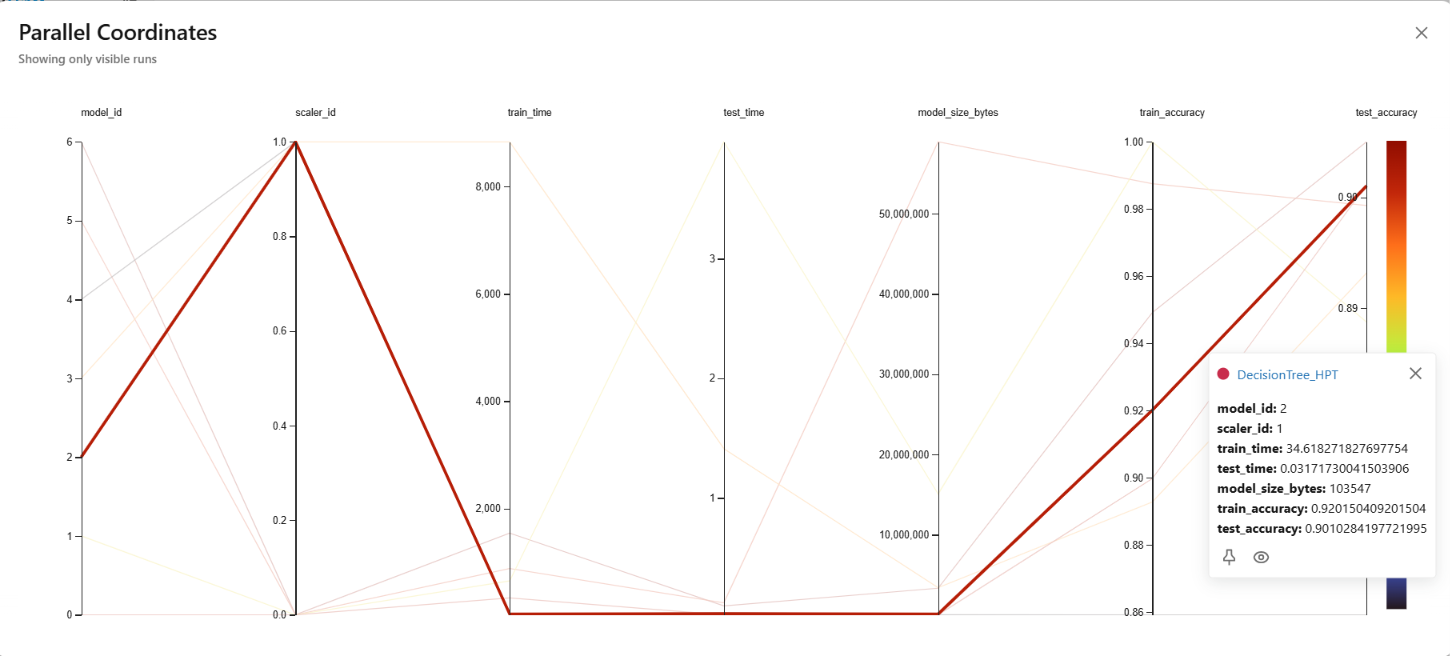

The Parallel Coordinates Plot is used to compare multiple machine learning models across different evaluation metrics and parameters in a single visualization. Each colored line represents one trained model, while each vertical axis represents a model attribute or performance metric.


Parameters Displayed

*   model_id - Unique identifier assigned to each machine learning model.
*  scaler_id -  Indicates the preprocessing scaler used (e.g., StandardScaler, MinMaxScaler).
* train_time - Time taken to train the model.
* test_time - Time required for prediction/testing.
* model_size_bytes - Storage size of the trained model.
* train_accuracy - Accuracy achieved on the training dataset.
* test_accuracy - Accuracy achieved on the testing dataset.



Analysis
* The model achieved 92.02% training accuracy and 90.10% testing accuracy, indicating good generalization with minimal overfitting.
* The testing time (0.0317 seconds) is very low, making it suitable for real-time predictions.
* The model size (103 KB) is relatively small, requiring less storage and memory.
* The small difference between training and testing accuracy suggests that the model performs consistently on unseen data.
* Compared to other models in the plot, the highlighted Decision Tree provides a balanced trade-off between accuracy, model size, and computational efficiency.

### Bank Term Deposit Subscription Predictor – Application Description


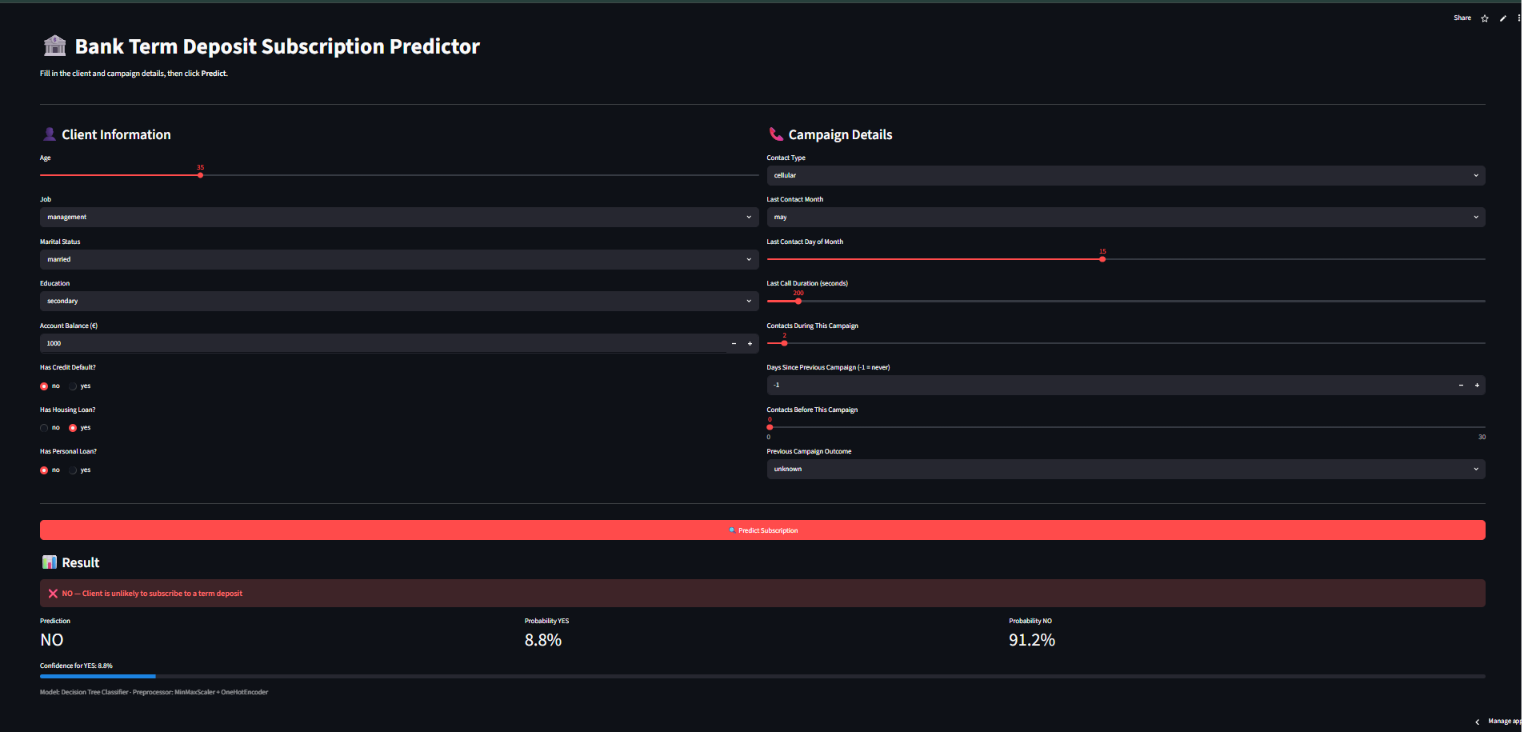

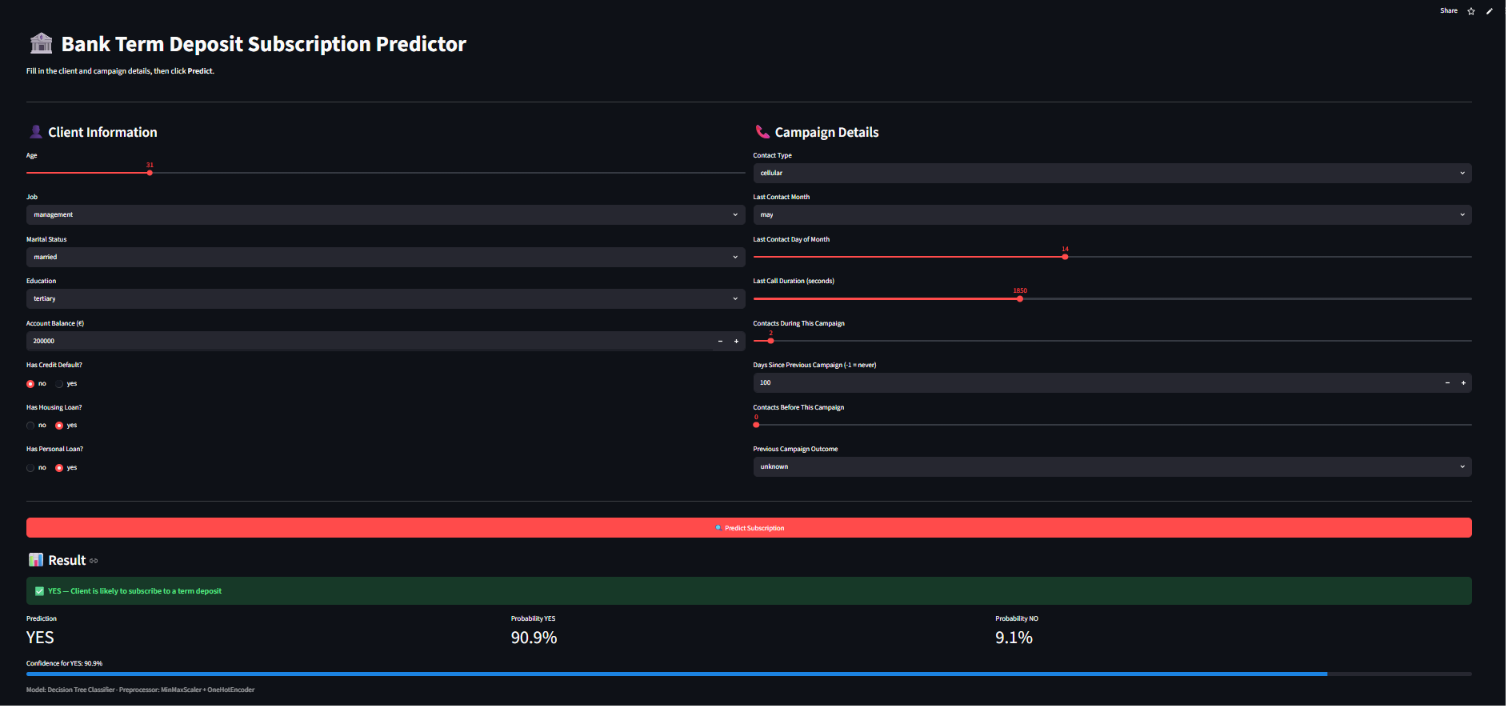

The Bank Term Deposit Subscription Predictor is a machine learning-based web application developed using Streamlit to predict whether a bank customer is likely to subscribe to a term deposit based on demographic, financial, and marketing campaign information. The system assists banks in identifying potential customers and improving the effectiveness of marketing campaigns.

Input Features

The application collects customer and campaign-related information through an interactive user interface.

* Client Information

* Age
* Job
* Marital Status
* Education Level
* Account Balance
* Credit Default Status
* Housing Loan Status
* Personal Loan Status

### Campaign Details

* Contact Type
* Last Contact Day
* Call Duration
* Number of Contacts During Campaign
* Days Since Previous Campaign
* Previous Contacts
* Previous Campaign Outcome

### Prediction Process

After entering the required details, the user clicks the “Predict Subscription” button. The trained machine learning model processes the inputs and predicts whether the customer will subscribe to a term deposit.

#### Result Interpretation

For the customer shown in the screenshot:

* Prediction: NO
* Probability of Subscription (YES): 8.8%
* Probability of Non-Subscription (NO): 91.2%
* Confidence for YES: 8.8%

The model indicates that the customer is unlikely to subscribe to a term deposit, as the probability of subscription is significantly lower than the probability of non-subscription.

#### Model Information

The prediction is generated using a:

* Decision Tree Classifier
* MinMaxScaler for numerical feature scaling
* OneHotEncoder for categorical feature encoding

#### Conclusion

This application provides a user-friendly interface for predicting customer subscription behavior in bank marketing campaigns. By leveraging machine learning techniques, it helps financial institutions focus their marketing efforts on customers with a higher likelihood of subscribing, thereby improving campaign efficiency and decision-making.

Streamlit Link : https://bankingcustomeraccountprediction-ewpfvv8gwjratwerw8tevc.streamlit.app/

Github Link : https://github.com/Palavalasamounika13/banking_customer_account_prediction_